In [2]:
# ==============================
# 📌 Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
file_path = r"C:\Users\Prathap\Desktop\Infosys Project\SentinelNet\Dataset\CICIDS\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"


df_original = pd.read_csv(file_path)
df = df_original.copy()


df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.000,0.000,...,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.000,0.000,...,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.000,0.000,...,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.000,0.000,...,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.000,0.000,...,20,0.000,0.000,0,0,0.000,0.000,0,0,BENIGN


In [5]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (225745, 79)

Columns:
 [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count',

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,225745.000,8879.619,19754.647,0.000,80.000,80.000,80.000,65532.000
Flow Duration,225745.000,16241648.528,31524374.232,-1.000,71180.000,1452333.000,8805237.000,119999937.000
Total Fwd Packets,225745.000,4.875,15.423,1.000,2.000,3.000,5.000,1932.000
Total Backward Packets,225745.000,4.573,21.755,0.000,1.000,4.000,5.000,2942.000
Total Length of Fwd Packets,225745.000,939.463,3249.403,0.000,26.000,30.000,63.000,183012.000
...,...,...,...,...,...,...,...,...
Active Min,225745.000,177620.089,784260.220,0.000,0.000,0.000,1862.000,100000000.000
Idle Mean,225745.000,10322143.419,21853028.149,0.000,0.000,0.000,8239725.000,120000000.000
Idle Std,225745.000,3611942.927,12756893.458,0.000,0.000,0.000,0.000,65300000.000
Idle Max,225745.000,12878128.944,26921263.646,0.000,0.000,0.000,8253838.000,120000000.000


In [8]:
df.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2633


In [10]:
cat_features = df.select_dtypes(include='object').columns

def unique_values(df, columns):
    for column in columns:
        print(f"Column: {column}")
        print(df[column].value_counts().head(10)) # top 10
        print("="*40)

unique_values(df, cat_features)


Column:  Label
 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


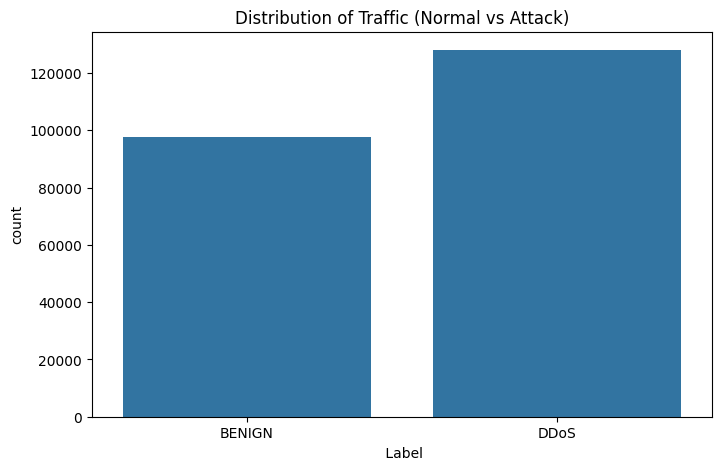

 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x=' Label', data=df)
plt.title("Distribution of Traffic (Normal vs Attack)")
plt.show()

print(df[' Label'].value_counts())

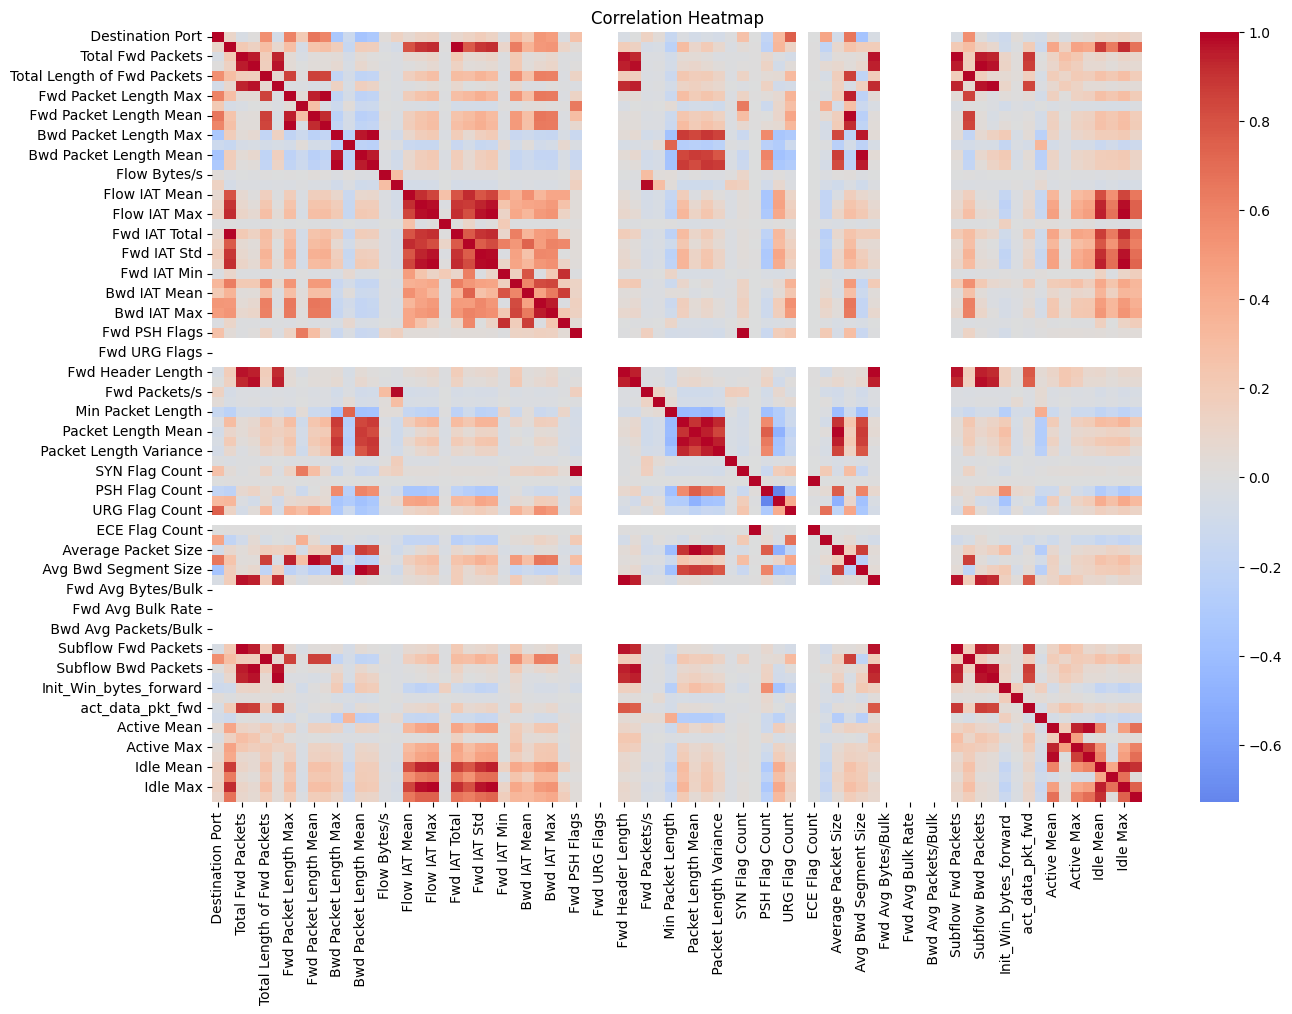

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


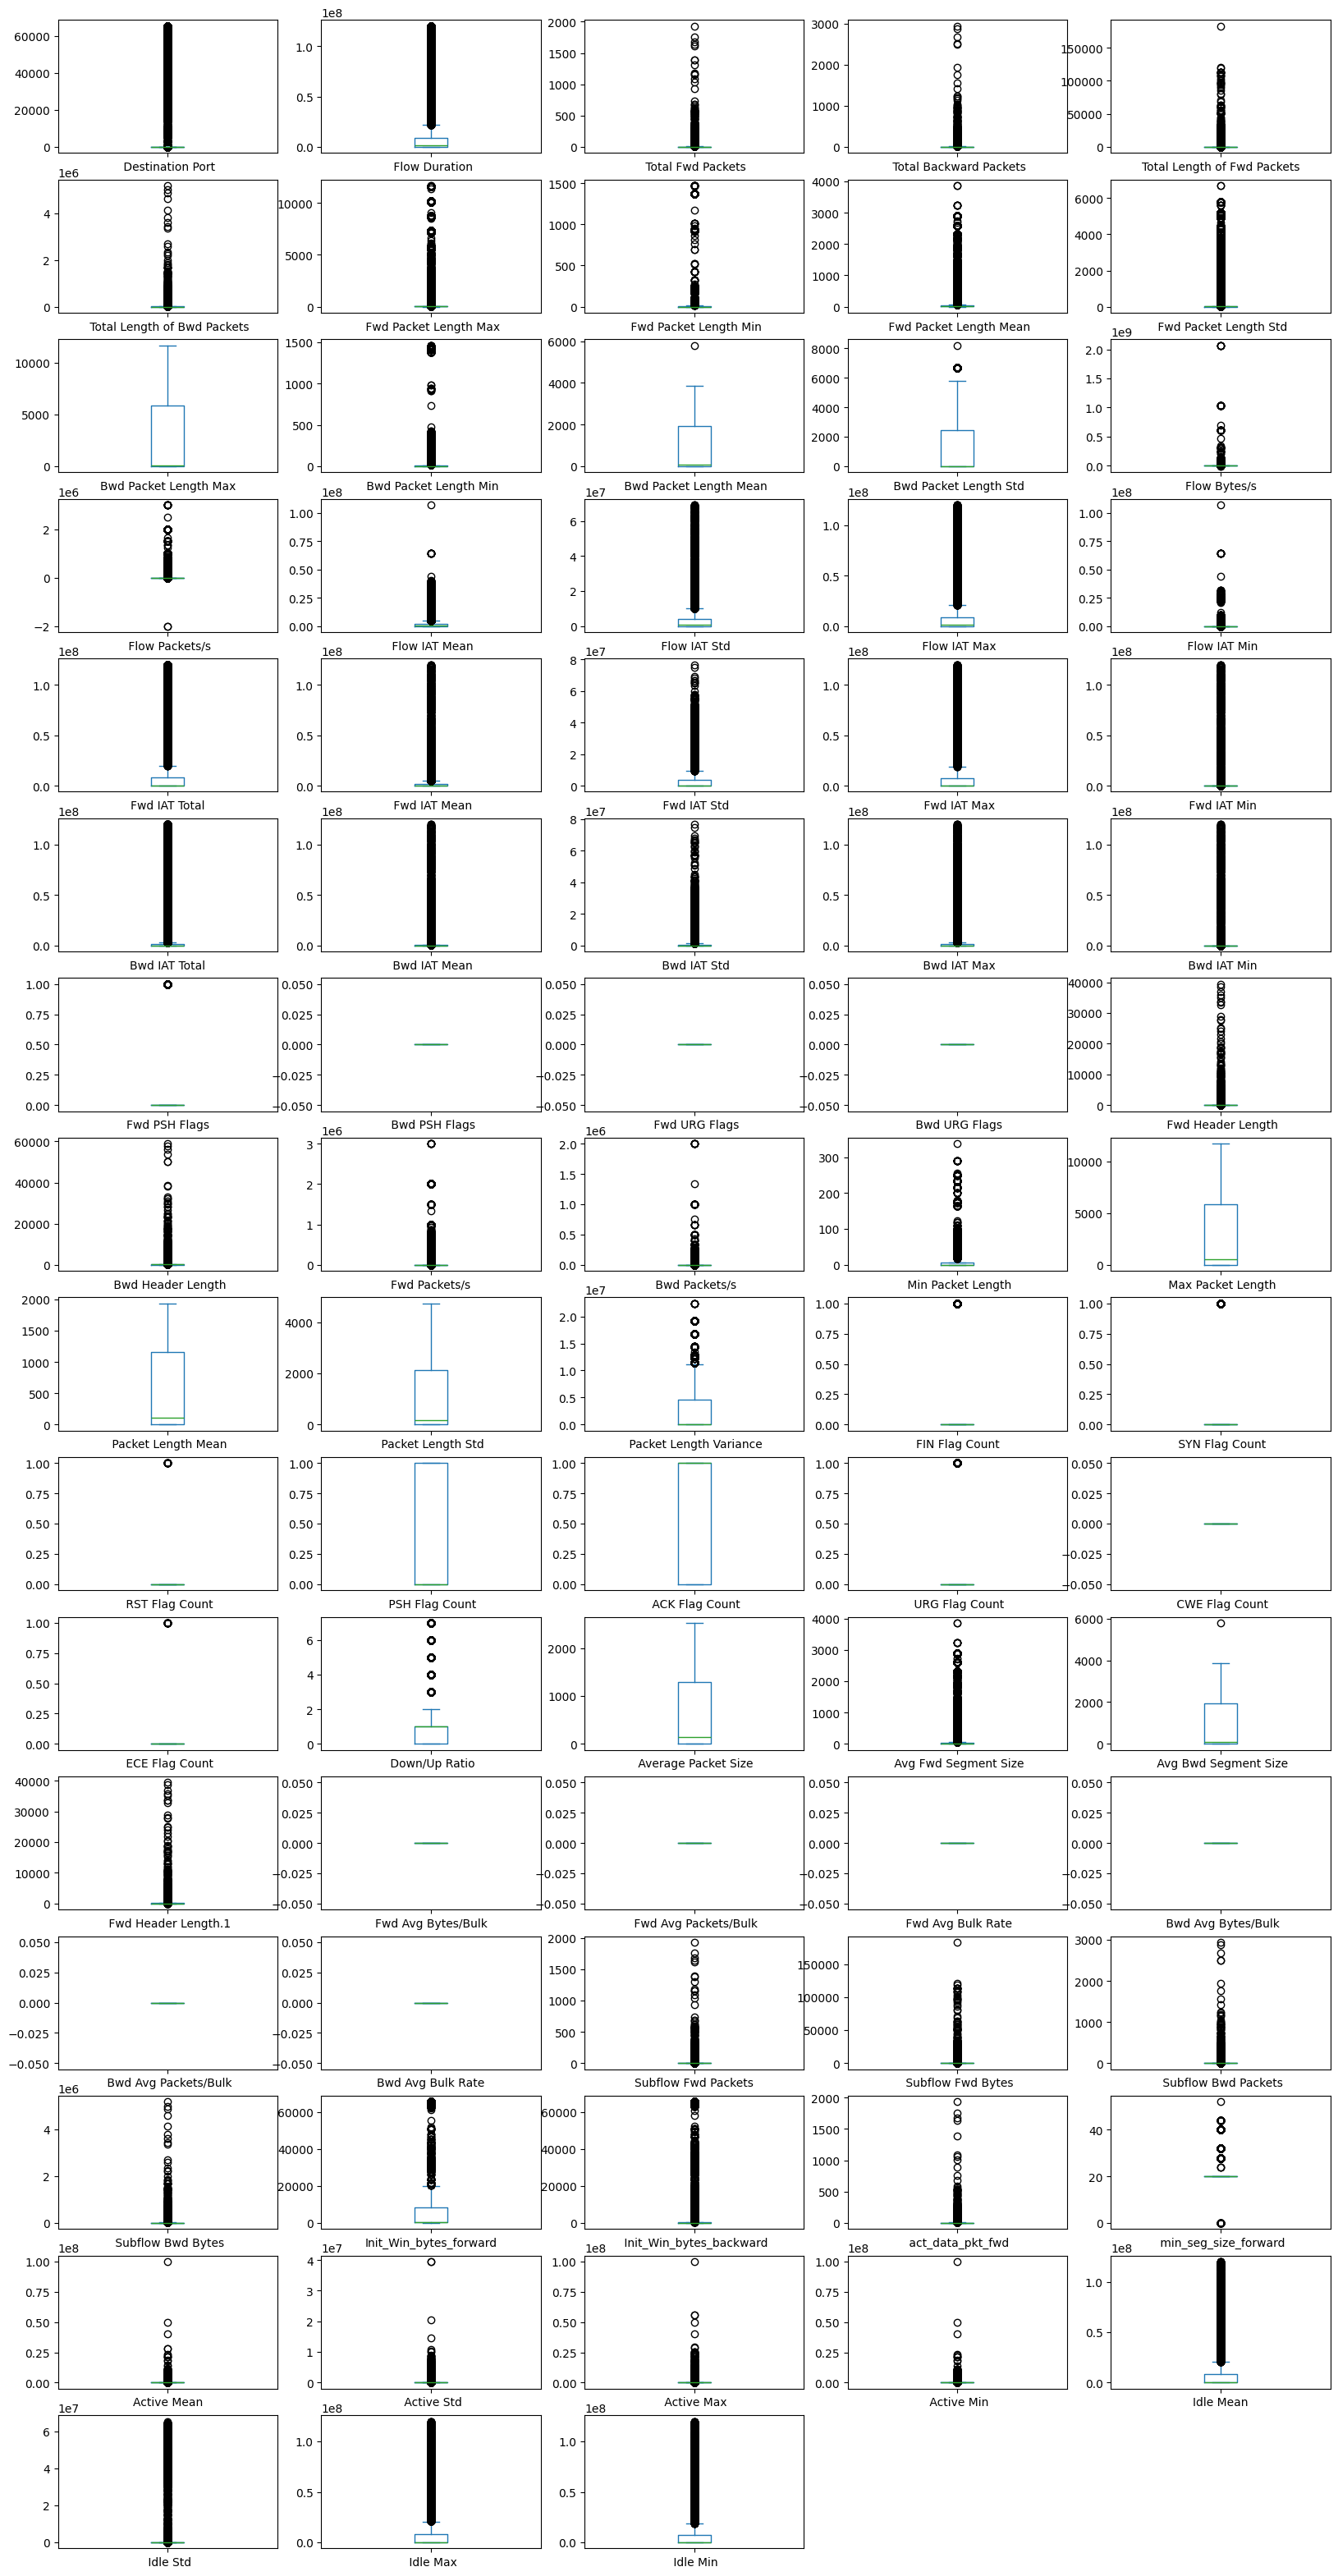

In [13]:
df[num_cols].plot(
    kind='box',
    subplots=True,
    layout=(int(np.ceil(len(num_cols)/5)), 5),
    figsize=(20, 40),
    sharex=False, sharey=False
)
plt.show()

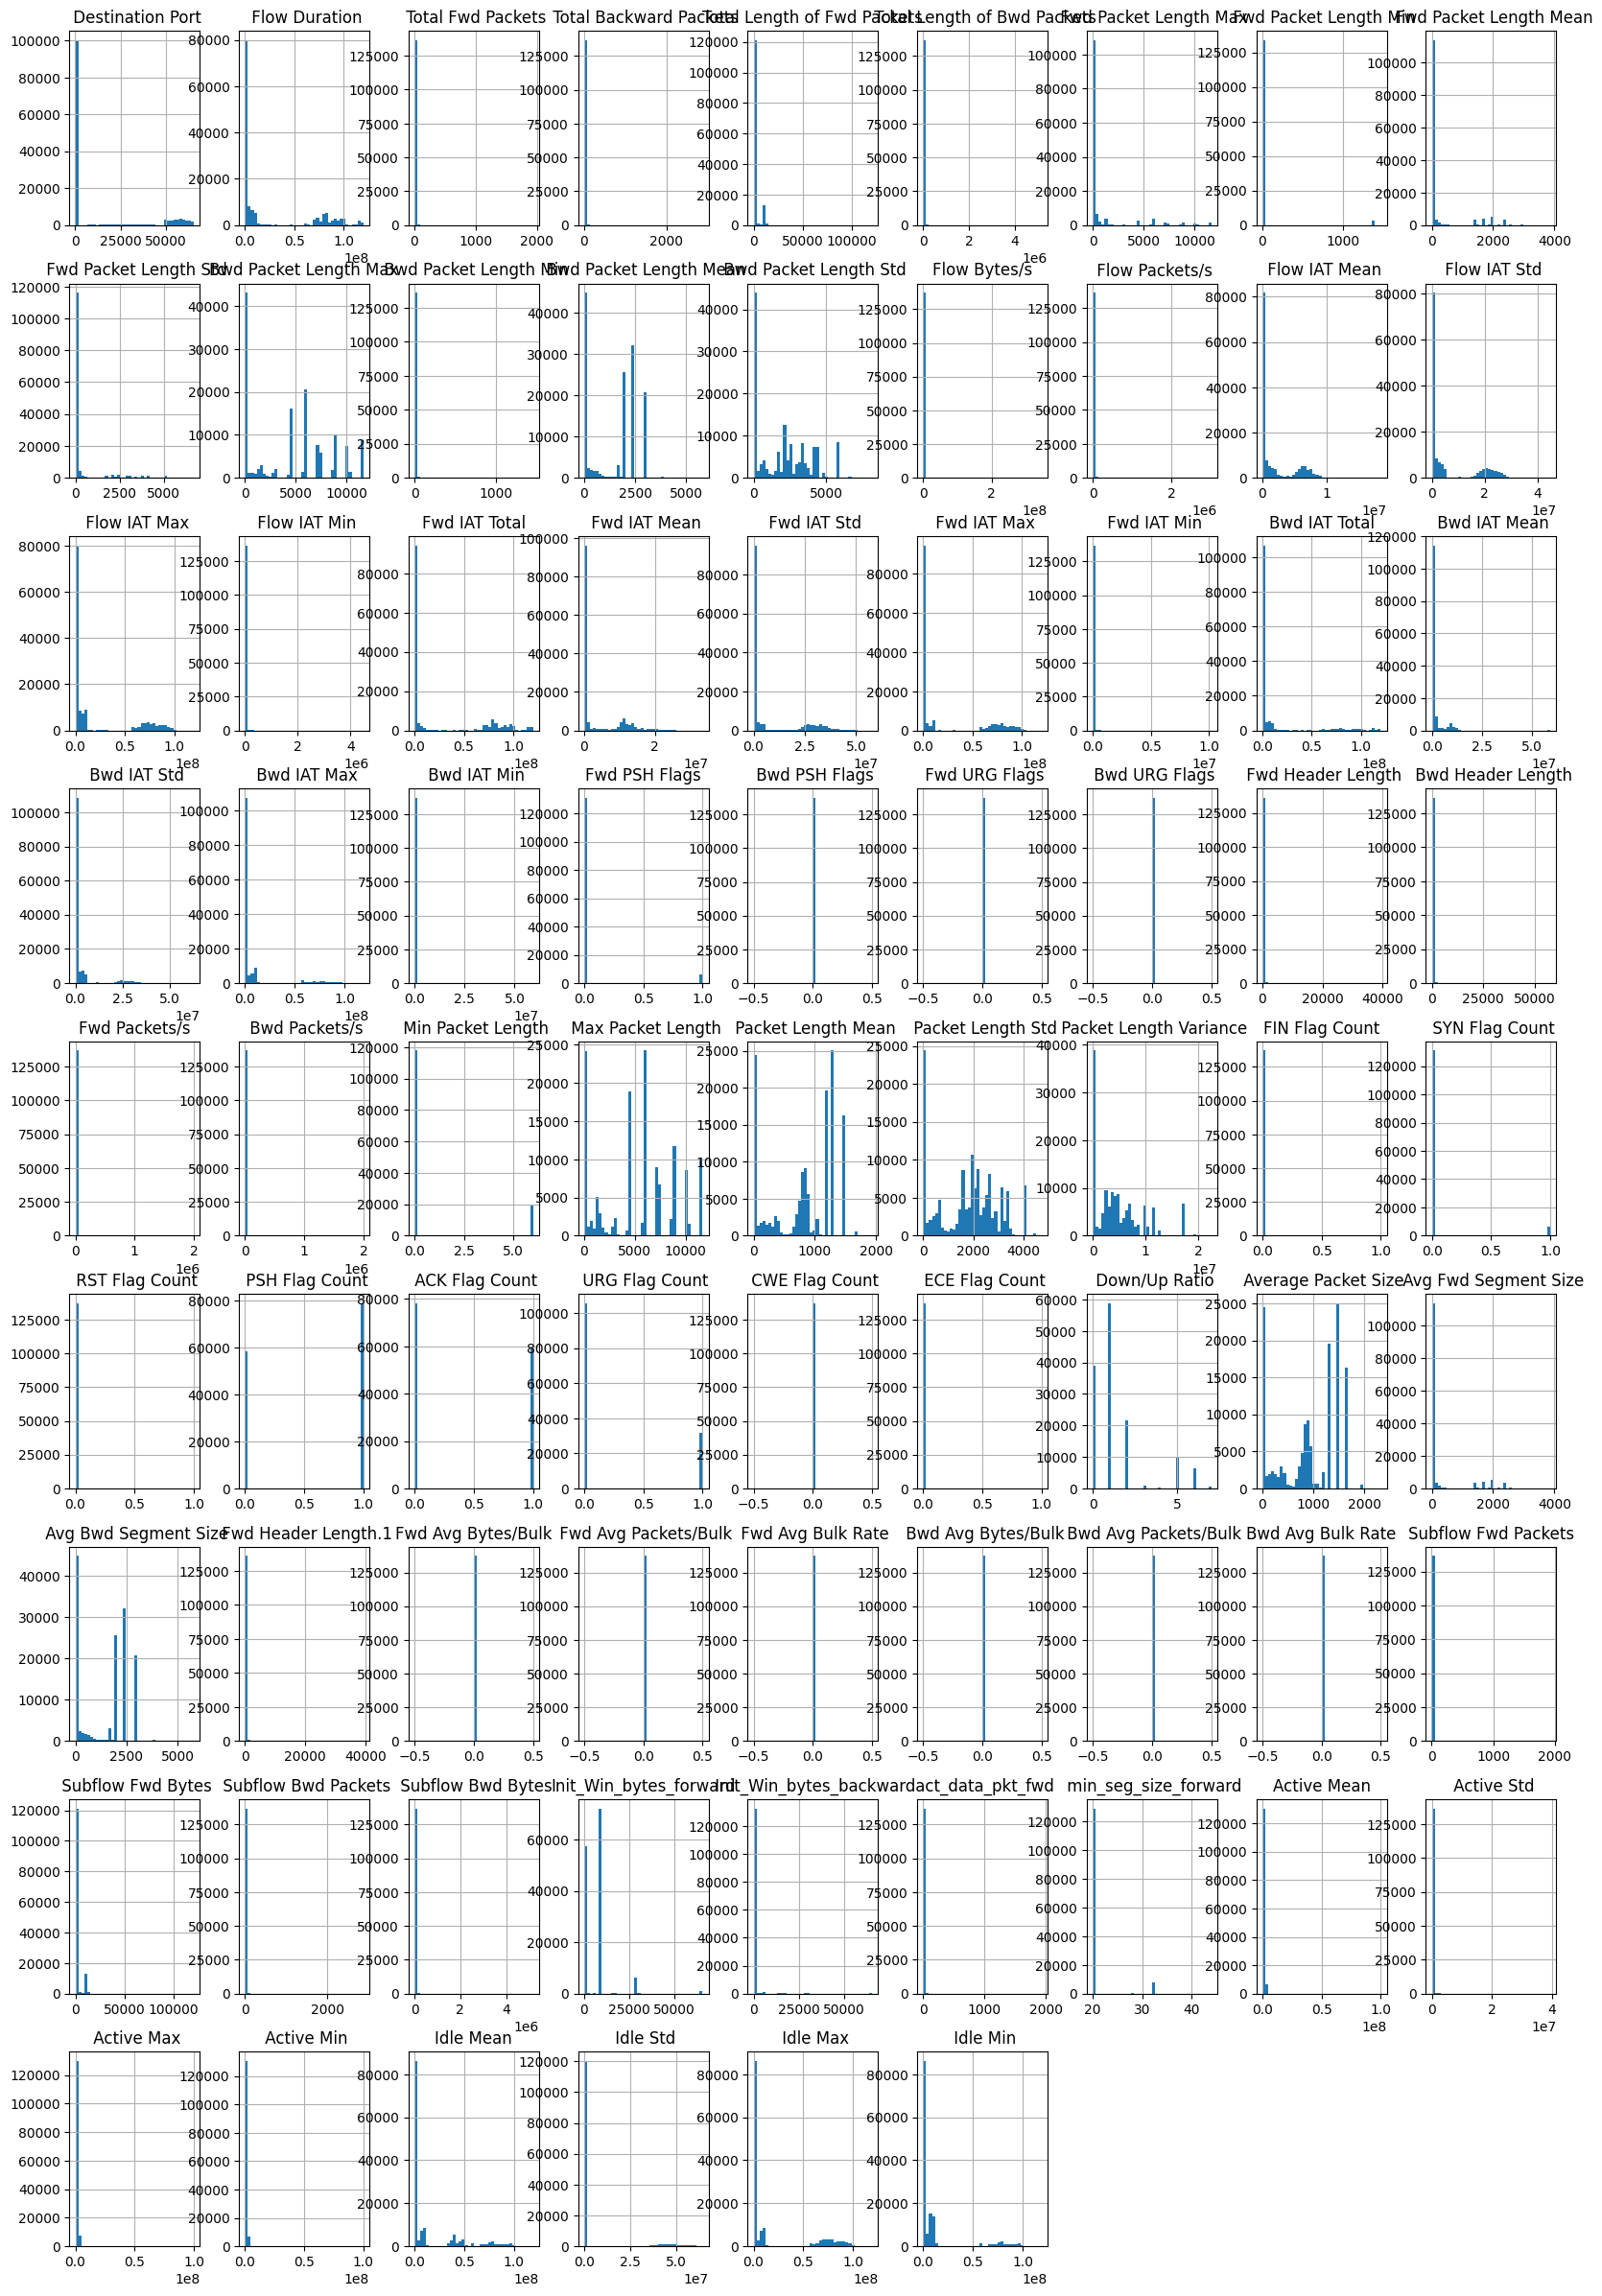

In [16]:
# Replace inf and -inf with NaN
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

# Optionally: replace negative values with NaN
df[num_cols] = df[num_cols].applymap(lambda x: np.nan if x < 0 else x)

# Drop or fill NaNs (better to drop for visualization)
df_clean = df[num_cols].dropna()

# Now plot histograms safely
df_clean.hist(bins=40, figsize=(20, 30))
plt.show()


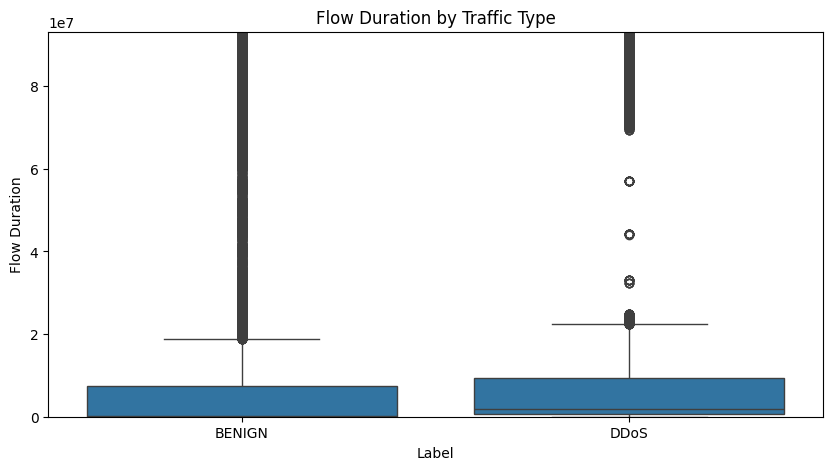

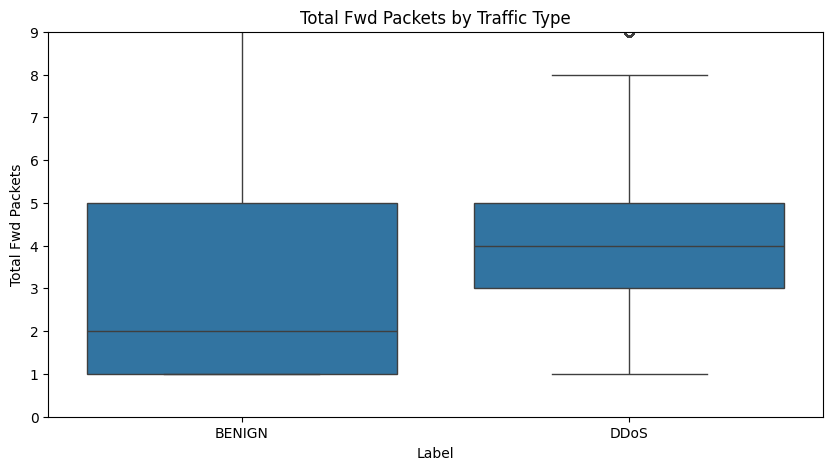

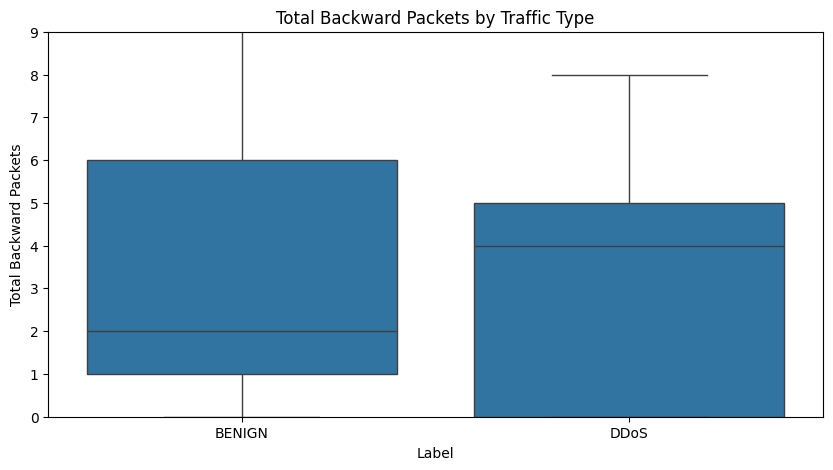

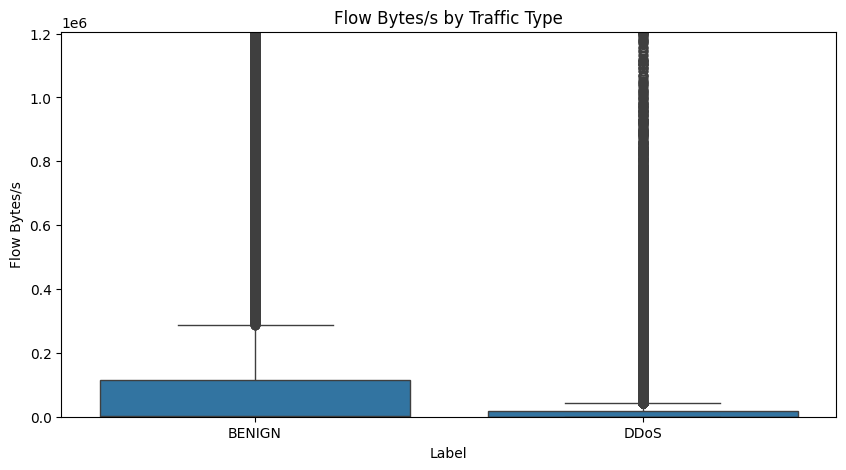

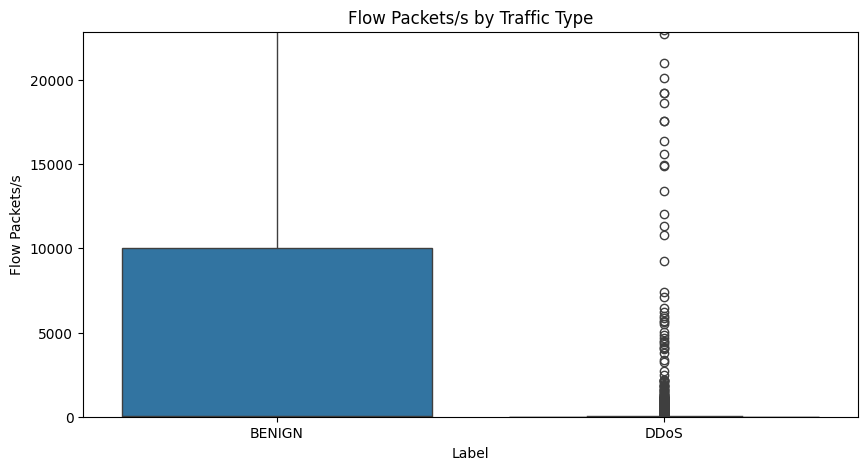

In [18]:
# Remove leading/trailing whitespaces from all column names
df.columns = df.columns.str.strip()

for feature in ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                'Flow Bytes/s', 'Flow Packets/s']:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='Label', y=feature, data=df)
    plt.ylim(0, df[feature].quantile(0.95))  # cut off extreme outliers
    plt.title(f"{feature} by Traffic Type")
    plt.show()